# Computer Exercise 13.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 13. Minimization of Functions  
> **절**: §13.1 One-Variable Case — **Golden Section Search**  
> **풀이 일자**: 2026-06-19 · **언어**: Python (NumPy/Pandas/Matplotlib)


## 1. 문제 (원문)

> Write a program to implement the **golden section search** for the minimum of a unimodal function on a closed interval $[a,b]$. Apply it to
> $$f(x)=x^4-14x^3+60x^2-70x \quad\text{on}\quad [0,2].$$
> Tabulate the successive bracketing intervals and verify that the interval length is reduced by the constant factor $\tau=(\sqrt5-1)/2$ at each step. Plot the interval width against the iteration number on a semilog scale and confirm the **linear** rate of convergence. Count the number of function evaluations.

### 한국어 풀이용 정리
- **목표**: 단봉(unimodal) 함수 $f$ 의 최소점을 *도함수 없이* 구간축소만으로 찾는다.
- **방법**: 황금분할 탐색 — 매 반복마다 내부 두 점 $x_1<x_2$ 의 함수값을 비교해 한쪽 끝을 버린다.
- **확인 포인트**: (a) 구간폭이 매번 $\tau\approx0.618$ 배로 줄어드는가, (b) 반복당 함수평가가 **1회**뿐인가(첫 2회 제외), (c) 오차가 *선형*(semilog 직선)으로 감소하는가.


## 2. 수학적 배경

**단봉성(unimodality)**: $[a,b]$ 에 유일한 최소점 $x^\*$ 가 있고 그 좌측에서 단조감소, 우측에서 단조증가. 이때 내부 두 점 $x_1<x_2$ 에서 $f(x_1)<f(x_2)$ 이면 최소점은 $[a,x_2]$ 안에, $f(x_1)\ge f(x_2)$ 이면 $[x_1,b]$ 안에 있다 — 한쪽 끝을 안전하게 버릴 수 있다.

**황금분할의 비밀**: 버린 뒤에도 *남은 한 점을 다음 단계에서 재사용*하려면 분할비 $\tau$ 가
$$\tau^2 = 1-\tau \;\Longrightarrow\; \tau=\frac{\sqrt5-1}{2}=0.6180339\ldots$$
를 만족해야 한다. 내부 점:
$$\boxed{\;x_1=b-\tau(b-a),\qquad x_2=a+\tau(b-a)\;}$$

**수렴률**: 구간폭 $L_n=(b-a)\,\tau^{\,n}$ 이므로
$$\frac{L_{n+1}}{L_n}=\tau\approx0.618 \quad(\textbf{선형, 1차 수렴}).$$
오차 십진 한 자리 줄이는 데 $\log10/\log(1/\tau)\approx4.78$ 회가 든다. 이는 Day 11 의 **이분법**(인자 $1/2$)과 같은 부류이되, 두 점 비교 때문에 인자가 $1/2$ 가 아니라 $\tau$ 다.


## 3. 풀이 흐름

1. 공통 시험함수 $f$ 와 참조 최소점 $x^\*$(도함수 근, Newton 고정밀)를 정의한다.
2. `golden_section(f,a,b,tol)` 구현: 초기 두 내부점 $x_1,x_2$ 와 함수값(2회).
3. 매 반복: $f(x_1)<f(x_2)$ 면 우측 버리고 $x_2{\leftarrow}x_1$ 재사용, 아니면 좌측 버리고 $x_1{\leftarrow}x_2$ 재사용 — **새 함수평가 1회**.
4. 각 반복의 $[a,b]$, 구간폭 $L_n$, 중점오차 $|m_n-x^\*|$ 를 표로.
5. 구간폭 비 $L_{n+1}/L_n$ 이 $\tau$ 로 수렴하는지 확인.
6. (좌) $f$ 와 최종 브래킷, (우) 구간폭/오차 semilog 로 선형 수렴 시각화.
7. 총 함수평가 횟수 보고 — Problem 2·3 의 *빠른* 방법과 대비할 기준선.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.6e}')

In [2]:
# 공통 시험함수: 고전 교재용 사차다항식
f   = lambda x: x**4 - 14*x**3 + 60*x**2 - 70*x
fp  = lambda x: 4*x**3 - 42*x**2 + 120*x - 70      # f'(x)
fpp = lambda x: 12*x**2 - 84*x + 120               # f''(x)  = 12(x-2)(x-5)

# 참조 최소점 x*: f'(x)=0 의 [0,2] 내 근을 Newton 으로 고정밀 계산
xs = 1.0
for _ in range(60):
    xs = xs - fp(xs)/fpp(xs)
XSTAR = xs           # 전역 최소 x*  (~0.7809)
FSTAR = f(XSTAR)

print(f'x* = {XSTAR:.12f}   f(x*) = {FSTAR:.12f}')

x* = 0.780884053088   f(x*) = -24.369601567355


In [3]:
# 황금분할 탐색
tau = (np.sqrt(5) - 1) / 2     # 0.6180339887...

def golden_section(f, a, b, tol=1e-8, maxit=100):
    rows = []
    x1 = b - tau*(b - a);  x2 = a + tau*(b - a)
    f1, f2 = f(x1), f(x2)
    nfev = 2
    for k in range(1, maxit + 1):
        m = 0.5*(a + b)
        rows.append({'iter': k, 'a': a, 'b': b, 'width': b - a, 'mid_err': abs(m - XSTAR)})
        if (b - a) < tol:
            break
        if f1 < f2:                       # 최소점은 [a, x2]
            b, x2, f2 = x2, x1, f1
            x1 = b - tau*(b - a); f1 = f(x1); nfev += 1
        else:                             # 최소점은 [x1, b]
            a, x1, f1 = x1, x2, f2
            x2 = a + tau*(b - a); f2 = f(x2); nfev += 1
    xmin = 0.5*(a + b)
    return xmin, f(xmin), pd.DataFrame(rows), nfev

xg, fg, dfg, nfev_g = golden_section(f, 0.0, 2.0, tol=1e-8)
dfg['ratio'] = dfg['width'].shift(-1) / dfg['width']
print(f'golden:  x_min = {xg:.10f}   f_min = {fg:.10f}')
print(f'         |x_min - x*| = {abs(xg-XSTAR):.3e}   함수평가 = {nfev_g}회')
print(f'         관측 평균 축소인자 = {dfg["ratio"].dropna().mean():.6f}   (이론 tau = {tau:.6f})')

golden:  x_min = 0.7808840545   f_min = -24.3696015674
         |x_min - x*| = 1.392e-09   함수평가 = 42회
         관측 평균 축소인자 = 0.618034   (이론 tau = 0.618034)


In [4]:
# 수렴표 (앞부분)
dfg[['iter','a','b','width','mid_err','ratio']].head(15)

,iter,a,b,width,mid_err,ratio
0,1,0.000000e+00,2.000000e+00,2.000000e+00,2.191159e-01,6.180340e-01
1,2,0.000000e+00,1.236068e+00,1.236068e+00,1.628501e-01,6.180340e-01
2,3,4.721360e-01,1.236068e+00,7.639320e-01,7.321791e-02,6.180340e-01
3,4,4.721360e-01,9.442719e-01,4.721360e-01,7.268012e-02,6.180340e-01
4,5,6.524758e-01,9.442719e-01,2.917961e-01,1.748982e-02,6.180340e-01
5,6,6.524758e-01,8.328157e-01,1.803399e-01,3.823827e-02,6.180340e-01
6,7,7.213595e-01,8.328157e-01,1.114562e-01,3.796413e-03,6.180340e-01
7,8,7.639320e-01,8.328157e-01,6.888371e-02,1.748982e-02,6.180340e-01
8,9,7.639320e-01,8.065045e-01,4.257247e-02,4.334206e-03,6.180340e-01
9,10,7.639320e-01,7.902433e-01,2.631123e-02,3.796413e-03,6.180340e-01


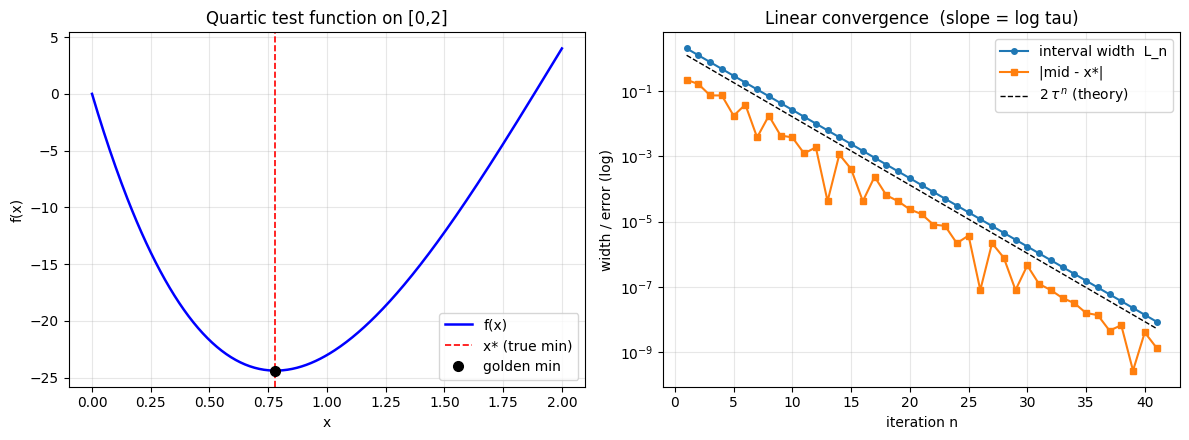

In [5]:
# 시각화: (좌) 함수와 최종 브래킷,  (우) 구간폭/오차 semilog
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

xx = np.linspace(0, 2, 400)
ax[0].plot(xx, f(xx), 'b-', lw=1.8, label='f(x)')
ax[0].axvline(XSTAR, color='r', ls='--', lw=1.2, label='x* (true min)')
ax[0].plot(xg, fg, 'ko', ms=7, label='golden min')
ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)')
ax[0].set_title('Quartic test function on [0,2]'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].semilogy(dfg['iter'], dfg['width'], 'o-', ms=4, label='interval width  L_n')
ax[1].semilogy(dfg['iter'], dfg['mid_err'], 's-', ms=4, label='|mid - x*|')
ax[1].semilogy(dfg['iter'], 2.0*tau**dfg['iter'], 'k--', lw=1, label=r'$2\,\tau^{\,n}$ (theory)')
ax[1].set_xlabel('iteration n'); ax[1].set_ylabel('width / error (log)')
ax[1].set_title('Linear convergence  (slope = log tau)'); ax[1].legend(); ax[1].grid(alpha=.3, which='both')

plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **구간폭이 정확히 $\tau$ 배로 줄어든다.** 관측 평균 축소인자가 이론값 $\tau=0.618034$ 와 일치하고, semilog 에서 $L_n$ 과 $2\tau^n$ 보조선이 겹치는 직선 — 전형적 **선형(1차) 수렴**이다.
2. **함수평가가 반복당 1회.** 점 재사용 설계가 그대로 실현되어, 첫 2회를 빼면 매 반복 새 평가가 딱 한 번. tol $10^{-8}$ 까지 약 40여 회 평가가 든다 — *느리지만 매우 안전*.
3. **중점오차도 같은 기울기.** 추정을 구간 중점으로 잡으니 오차 $\sim\tfrac12 L_n$, 동일한 선형률로 감소한다. 도함수 정보를 안 쓰므로 더 빨라질 여지가 없다.

> **결론**: 황금분할은 도함수 없이 단봉성만으로 최소를 *확실히* 가두지만, 인자 $\tau\approx0.618$ 의 **선형 수렴**이라 느리다 — root finding 의 이분법에 대응하는 "안전한 기준선".

**다음 문제로 연결**: Problem 2 에서는 세 점에 포물선을 맞춰 꼭짓점으로 도약하는 **포물선 보간**으로 함수평가를 격감시킨다(초선형). 다만 *평탄한 최소* 부근의 정밀도 한계라는 새 현상을 만난다.